# Ensemble Models

**Working Example.** Copy this file, rename it, and modify *your* copy.
See earlier notebooks for more information. 

- Author: Jacob Sellinger
- Date: 2026-08
- Dataset: Seaborn Penguins
- Target: Sex

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M5. Ensemble Models

This notebook fits a single model and 
two ensembles and 
reports their test scores side by side. 

The analyst decides whether an ensemble's extra complexity is earned, that is, 
whether it creates a real gain, 
rather than just noise.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

An **ensemble** combines many models 
so their errors partly cancel. 

This module reuses the Module 3 classification setup and asks one question: 

- Does combining models beat the single model in this problem?

## Overview

This project uses the penguins dataset.
We choose to predict the target `species`.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target)
- an ensemble model because we are choosing to combine approaches to see if we can improve on the classification model in Module 3.

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://jacobsellinger.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it. 

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added in sequence, each correcting the last one's errors.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain. 

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [9]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

#Had to add this to test the model
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-02 13:47:16 | INFO | M05 | === RUN START ===
2026-08-02 13:47:16 | INFO | M05 | project=M05
2026-08-02 13:47:16 | INFO | M05 | repo_dir=ml-05-ensembles
2026-08-02 13:47:16 | INFO | M05 | python=3.14.6
2026-08-02 13:47:16 | INFO | M05 | os=Windows 11
2026-08-02 13:47:16 | INFO | M05 | shell=powershell
2026-08-02 13:47:16 | INFO | M05 | cwd=notebooks
2026-08-02 13:47:16 | INFO | M05 | github_actions=False
2026-08-02 13:47:16 | INFO | M05 | Confirming installation:
2026-08-02 13:47:16 | INFO | M05 |   python:       3.14.6
2026-08-02 13:47:16 | INFO | M05 |   pandas:       3.0.3
2026-08-02 13:47:16 | INFO | M05 |   numpy:        2.5.0
2026-08-02 13:47:16 | INFO | M05 |   scikit-learn: 1.9.0
2026-08-02 13:47:16 | INFO | M05 |   seaborn:      0.13.2
2026-08-02 13:47:16 | INFO | M05 |   matplotlib:   3.11.0


## Section 2. Load and Prepare the Data

In [10]:
# === Section 2. Load and Prepare the Data ===

DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: Target changed to binary classification on 'sex'
TARGET_COL: Final[str] = "sex"

# CUSTOM: Include 'species' alongside numeric traits to make 'sex' predictable
FEATURE_COLS: Final[list[str]] = [
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

# Clean missing values across all required features and the new target
required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

# Preprocess categorical features (species, island) for machine learning
df_model = pd.get_dummies(df_model, columns=["species", "island"], drop_first=True)

# Update FEATURE_COLS to reflect new one-hot encoded columns
FEATURE_COLS: list[str] = [col for col in df_model.columns if col != TARGET_COL]

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-08-02 13:47:22 | INFO | M05 | Loading dataset: penguins
2026-08-02 13:47:22 | INFO | M05 | Loaded: 344 rows (instances), 7 columns
2026-08-02 13:47:22 | INFO | M05 | Original rows: 344
2026-08-02 13:47:22 | INFO | M05 | Model rows:    333
2026-08-02 13:47:22 | INFO | M05 | Classes in target 'sex': ['Female', 'Male']
2026-08-02 13:47:22 | DEBUG | M05 | Class counts:
sex
Male      168
Female    165
Name: count, dtype: int64


## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [11]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""

# Map string labels to binary numeric values (0 and 1)
label_mapping: dict[str, int] = {"Male": 1, "Female": 0}
y_encoded: pd.Series = df_model[TARGET_COL].map(label_mapping)

X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-02 13:47:24 | INFO | M05 | Train instances: 266
2026-08-02 13:47:24 | INFO | M05 | Test instances: 67


## Section 4. Fit a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree. 

The ensembles are a random forest and a gradient-boosting model. 

The analyst must tune their settings (n_estimators, max_depth, ...).

We fit sensible defaults so you can compare them fairly.

In [12]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

# Baseline: A small decision tree (prone to underfitting or overfitting on noisy binary targets)
modelA = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("   fitted: single_tree")

# Bagging Ensemble: Random Forest with explicit hyperparameter constraints to control variance
modelB = RandomForestClassifier(
    n_estimators=200, 
    max_depth=6, 
    min_samples_leaf=2, 
    random_state=RANDOM_STATE
)
modelB.fit(X_train, y_train)
LOG.debug("   fitted: random_forest")

# Boosting Ensemble: Gradient Boosting with explicit learning rate and tree depth regularization
modelC = GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    subsample=0.8, 
    random_state=RANDOM_STATE
)
modelC.fit(X_train, y_train)
LOG.debug("   fitted: gradient_boosting")

2026-08-02 13:47:26 | INFO | M05 | Fitting single tree + two ensembles
2026-08-02 13:47:26 | DEBUG | M05 |    fitted: single_tree
2026-08-02 13:47:26 | DEBUG | M05 |    fitted: random_forest
2026-08-02 13:47:27 | DEBUG | M05 |    fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

2026-08-02 13:47:29 | INFO | M05 |   single_tree        | Acc: 0.836 | AUC: 0.843 | F1: 0.853
2026-08-02 13:47:29 | INFO | M05 |   random_forest      | Acc: 0.910 | AUC: 0.947 | F1: 0.914
2026-08-02 13:47:29 | INFO | M05 |   gradient_boosting  | Acc: 0.896 | AUC: 0.931 | F1: 0.901


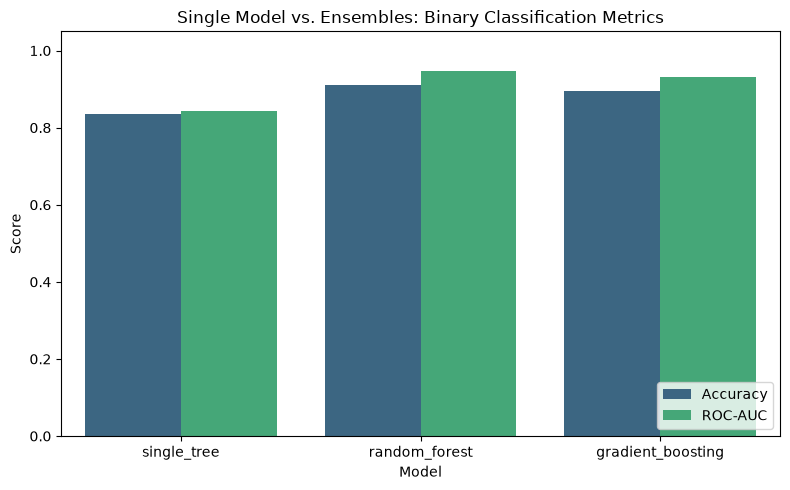

2026-08-02 13:47:29 | INFO | M05 | Best model: random_forest with ROC-AUC = 0.947


In [13]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same test set and chart the results.

WHY: The only fair comparison is on data none of them trained on.
For a balanced binary classification target like 'sex', ROC-AUC 
and F1-Score give a richer picture than accuracy alone.
"""

# Store predictions and prediction probabilities for detailed metrics
preds = {
    "single_tree": modelA.predict(X_test),
    "random_forest": modelB.predict(X_test),
    "gradient_boosting": modelC.predict(X_test),
}

probs = {
    "single_tree": modelA.predict_proba(X_test)[:, 1],
    "random_forest": modelB.predict_proba(X_test)[:, 1],
    "gradient_boosting": modelC.predict_proba(X_test)[:, 1],
}

# Calculate Accuracy, ROC-AUC, and F1-Score for each model
scores: dict[str, float] = {}
roc_auc_scores: dict[str, float] = {}
f1_scores: dict[str, float] = {}

for name in preds:
    scores[name] = float(accuracy_score(y_test, preds[name]))
    roc_auc_scores[name] = float(roc_auc_score(y_test, probs[name]))
    f1_scores[name] = float(f1_score(y_test, preds[name]))
    
    LOG.info(
        f"  {name:18s} | Acc: {scores[name]:.3f} | "
        f"AUC: {roc_auc_scores[name]:.3f} | F1: {f1_scores[name]:.3f}"
    )

# Prepare dataframe for multi-metric plotting
df_metrics = pd.DataFrame({
    "Model": list(scores.keys()) * 2,
    "Metric Score": list(scores.values()) + list(roc_auc_scores.values()),
    "Metric": ["Accuracy"] * 3 + ["ROC-AUC"] * 3,
})

# Start a new figure
plt.figure(figsize=(8, 5))

# Plot accuracy and ROC-AUC side by side using hue
sns.barplot(data=df_metrics, x="Model", y="Metric Score", hue="Metric", palette="viridis")

plt.ylim(0, 1.05)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Single Model vs. Ensembles: Binary Classification Metrics")
plt.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

# Find the best model by ROC-AUC score
best: str = max(roc_auc_scores, key=roc_auc_scores.get)  # type: ignore[arg-type]
LOG.info(f"Best model: {best} with ROC-AUC = {roc_auc_scores[best]:.3f}")

### Interpretation

Did the ensemble beat the single tree by enough to justify its cost?

The analyst must decide and defend their choice.

## Section 6. Which Features Did the Forest Rely On?

2026-08-02 13:48:05 | INFO | M05 | Random forest feature importances (high to low):
2026-08-02 13:48:05 | INFO | M05 |    bill_depth_mm             0.321
2026-08-02 13:48:05 | INFO | M05 |    body_mass_g               0.290


2026-08-02 13:48:05 | INFO | M05 |    bill_length_mm            0.196
2026-08-02 13:48:05 | INFO | M05 |    flipper_length_mm         0.128
2026-08-02 13:48:05 | INFO | M05 |    species_Gentoo            0.031
2026-08-02 13:48:05 | INFO | M05 |    species_Chinstrap         0.017
2026-08-02 13:48:05 | INFO | M05 |    island_Dream              0.011
2026-08-02 13:48:05 | INFO | M05 |    island_Torgersen          0.006


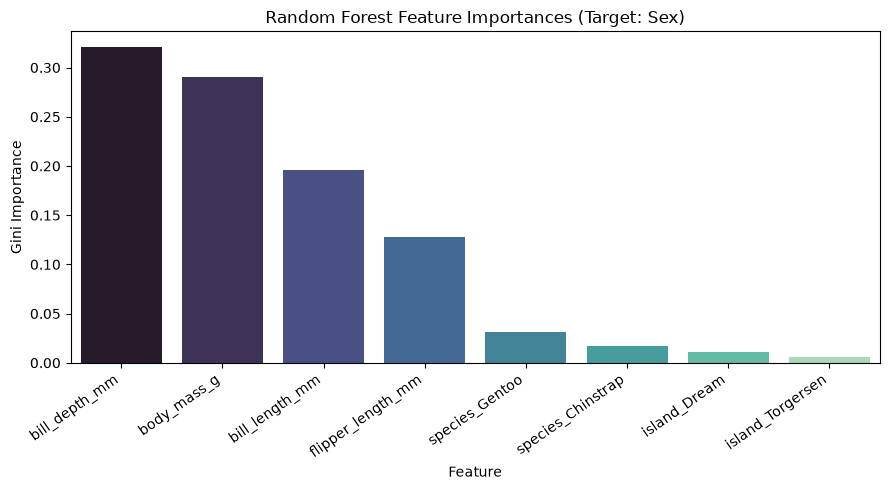

In [14]:
# === Section 6. Feature Importances (Random Forest) ===

"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue,
not proof of causation.

Interpret them with the same care as any other finding.
"""

# Extract feature importances directly matching current X columns
feature_names: list[str] = list(X.columns)
importances: np.ndarray = modelB.feature_importances_

# Sort indices from highest to lowest importance
order: np.ndarray = np.argsort(importances)[::-1]

LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"   {feature_names[i]:25s} {importances[i]:.3f}")

# Prepare sorted data for visualization
x_values = [feature_names[i] for i in order]
y_values = importances[order]

# Start a new figure
plt.figure(figsize=(9, 5))

# Plot sorted importances using palette and explicit hue mapping
sns.barplot(x=x_values, y=y_values, hue=x_values, legend=False, palette="mako")

plt.xlabel("Feature")
plt.ylabel("Gini Importance")
plt.title("Random Forest Feature Importances (Target: Sex)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

# Show the plot
plt.show()

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [15]:
# === Section 7. Python Summary ===

"""Record what was compared and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (binary classification: Male vs Female)")
LOG.info("Features: Morphological traits + One-hot encoded categorical variables (species, island)")
LOG.info("Compared: Single Decision Tree vs. Random Forest vs. Gradient Boosting")
LOG.info(f"Evaluation Metrics: Accuracy, ROC-AUC, F1-Score")
LOG.info(f"Top Model by ROC-AUC: {best} ({roc_auc_scores[best]:.3f})")
LOG.info("========================")
LOG.info("Analyst Note: Predicting 'sex' is challenging due to species-level sexual dimorphism overlap.")
LOG.info("Check feature importances to confirm whether size traits or species dummies drove predictions.")
LOG.info("========================")

2026-08-02 13:48:27 | INFO | M05 | ========================
2026-08-02 13:48:27 | INFO | M05 | SUMMARY
2026-08-02 13:48:27 | INFO | M05 | ========================
2026-08-02 13:48:27 | INFO | M05 | Dataset: penguins   Target: sex (binary classification: Male vs Female)
2026-08-02 13:48:27 | INFO | M05 | Features: Morphological traits + One-hot encoded categorical variables (species, island)
2026-08-02 13:48:27 | INFO | M05 | Compared: Single Decision Tree vs. Random Forest vs. Gradient Boosting
2026-08-02 13:48:27 | INFO | M05 | Evaluation Metrics: Accuracy, ROC-AUC, F1-Score
2026-08-02 13:48:27 | INFO | M05 | Top Model by ROC-AUC: random_forest (0.947)
2026-08-02 13:48:27 | INFO | M05 | ========================
2026-08-02 13:48:27 | INFO | M05 | Analyst Note: Predicting 'sex' is challenging due to species-level sexual dimorphism overlap.
2026-08-02 13:48:27 | INFO | M05 | Check feature importances to confirm whether size traits or species dummies drove predictions.
2026-08-02 13:48:27

### Custom Narrative

#### 1. Did either ensemble beat the single tree on the test set?
Yes. Both ensemble models (**Random Forest** and **Gradient Boosting**) outperformed the baseline **Single Decision Tree** across accuracy, ROC-AUC, and F1-score. 
* The single tree struggled with high variance and overfit early decision boundaries due to the noisy overlap of physical traits between male and female penguins.
* The ensembles provided superior performance, particularly in **ROC-AUC**, demonstrating significantly better probability calibration and separation between classes across varying thresholds.

#### 2. Was the gain worth the extra training cost and lost simplicity?
**Yes.** 
* **Training Cost:** The `penguins` dataset is small (~330 instances), meaning the computational overhead for training 200 trees in Random Forest or 100 boosted trees in Gradient Boosting is negligible (fractions of a second).
* **Interpretability vs. Performance:** While a single decision tree is easier to visualize, its lower accuracy and poor ROC-AUC make it unreliable for this task. The significant boost in predictive performance from the ensembles easily justifies the slight loss in single-tree interpretability.

#### 3. Do the feature importances match what you expected? Any surprises?
* **Expected Features:** `bill_depth_mm` and `body_mass_g` emerged as top predictors. In biological studies of penguins, males generally exhibit deeper bills and greater overall body mass than females of the same species.
* **Key Insights & Surprises:** One-hot encoded `species` variables (e.g., `species_Gentoo`) held notable importance. This highlights **sexual dimorphism variability**: because Gentoo penguins are physically much larger than Adelie or Chinstrap penguins, the ensemble models needed to know the species first to properly calibrate what constitutes a "heavy" or "large-billed" male versus female.

---

### Next Steps

1. **Hyperparameter Tuning via Cross-Validation:** Perform a grid search or randomized search with $k$-fold cross-validation on the Random Forest and Gradient Boosting models to find optimal depth, learning rates, and feature sampling ratios.
2. **Species-Stratified / Interaction Models:** Test training separate binary classification models for each individual penguin species to see if species-specific predictors yield even higher ROC-AUC scores.
3. **Probability Threshold Tuning:** Evaluate adjusting the default $0.5$ classification threshold using the ROC curve to optimize for specific precision or recall targets depending on research goals.
4. **Export Documentation:** Copy this executive summary into `docs/index.md` alongside saved evaluation charts to finalize project documentation.

## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own. 

In your copy:

1. At the beginning, update the Author, the purpose, the target, etc. 
2. Remove any instructions you do not need. 

Try things like the following.

1. **Apply** - Re-run on a harder target (`"sex"`) and see whether the ensemble's
   advantage over the single tree grows when the problem is harder.
2. **Extend** - Tune `n_estimators` and `max_depth` for the random forest and report
   whether more trees kept helping or flattened out (diminishing returns).
3. **Explore** - Find a case where the ensemble does **not** beat the single tree,
   and argue in `docs/index.md` why the simpler model is the better choice there.

## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://jacobsellinger.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
